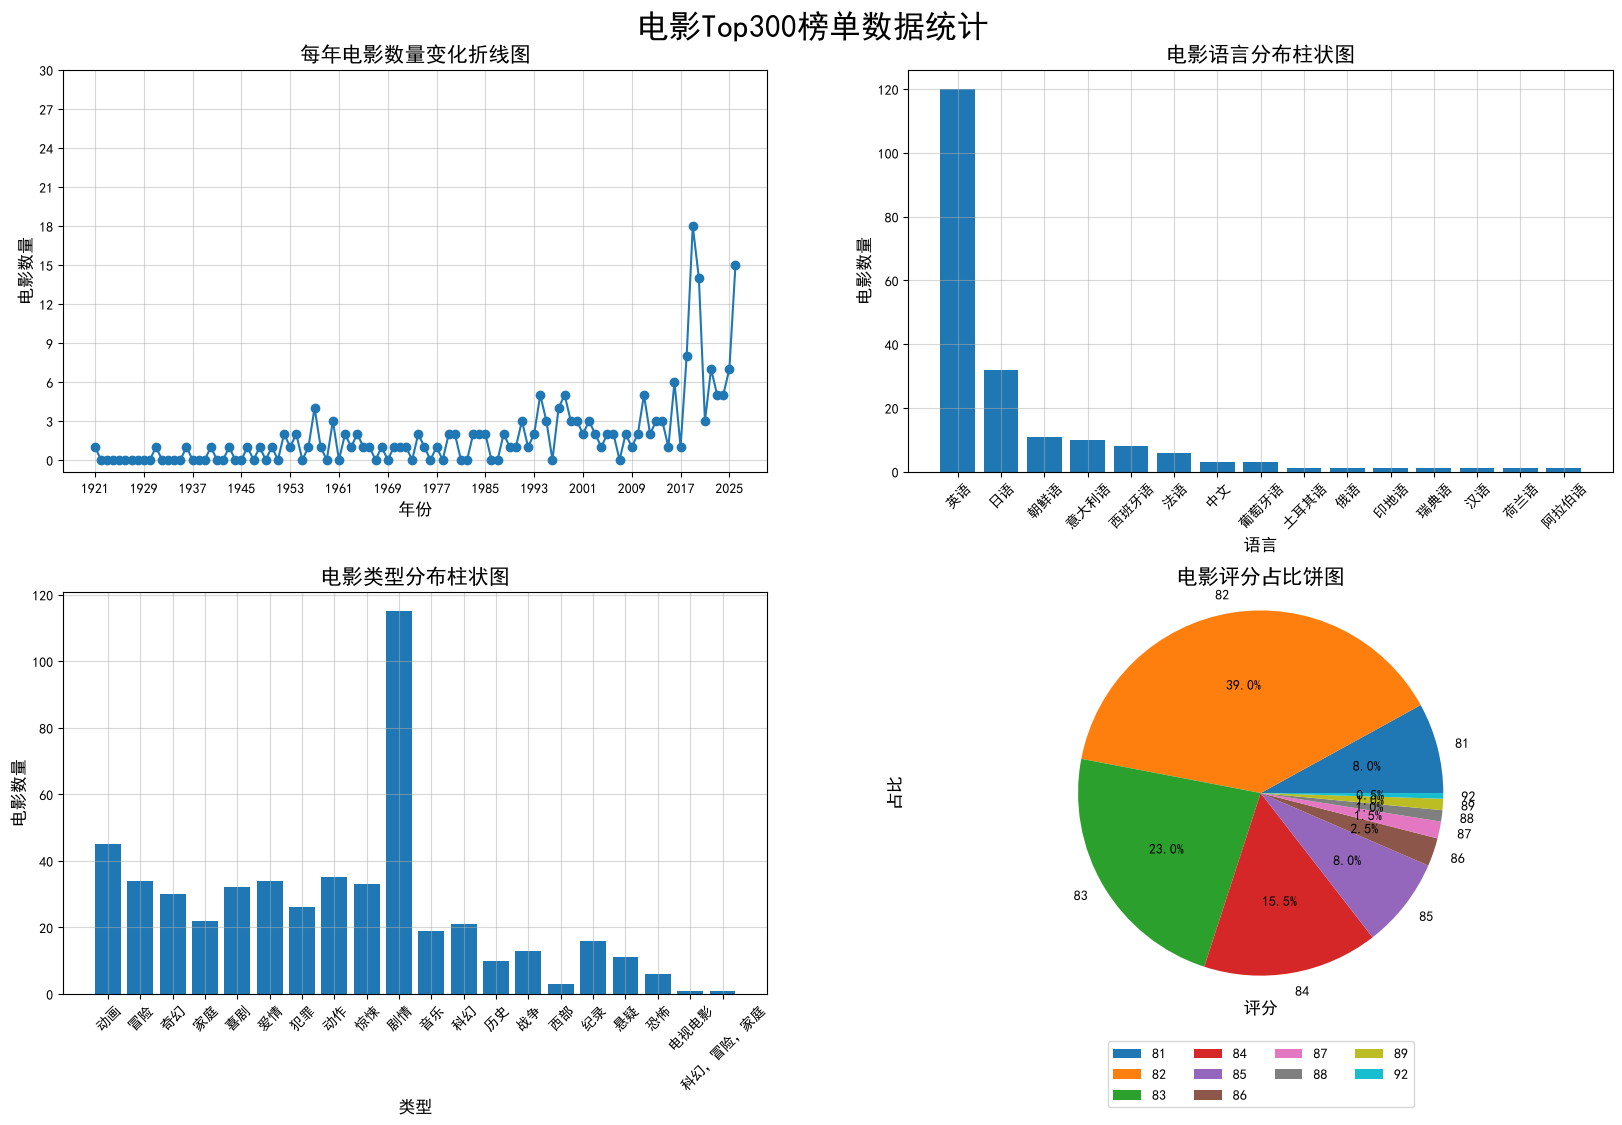

In [77]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from pydeck.data_utils.viewport_helpers import bbox_to_zoom_level
from sympy.benchmarks.bench_meijerint import alpha

# 展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']


#创建子图
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (20, 12))

fig.subplots_adjust(hspace=0.3,wspace=0.2)

fig.suptitle('电影Top300榜单数据统计',fontsize = 23,x =0.5,y= 0.93) # 添加标题

axes1:Axes = ax[0][0]
axes2:Axes = ax[0][1]
axes3:Axes = ax[1][0]
axes4:Axes = ax[1][1]


#加载数据
data = pd.read_csv('../data/movie_list.csv', usecols=['电影名', '电影年份', '电影数据', '电影标签', '电影时长', '电影评分', '电影语言'])
data['电影年份'] = data['电影年份'].str.replace('(', '', regex=False)
data['电影年份'] = data['电影年份'].str.replace(')', '', regex=False)
data['电影年份'] = data['电影年份'].astype(int)
#分组统计
year_count = data.groupby('电影年份')['电影年份'].count()
#x轴数据
min_year = int(year_count.index.min())
max_year = int(year_count.index.max())
x = [i for i in range(min_year, max_year+1)]

#y轴数据
y = [int(year_count.get(i,0)) for i in x]


axes1.plot(x, y, marker='o')
axes1.set_title('每年电影数量变化折线图',fontsize = 15)
axes1.set_xlabel('年份',fontsize = 12)
axes1.set_ylabel('电影数量',fontsize = 12)

axes1.set_xticks(x[::8])
y_ticks = [i for i in range(0,31,3)]
axes1.set_yticks(y_ticks)
axes1.grid(alpha = 0.5)


# 2.柱状图
language_data = data.groupby('电影语言')['电影语言'].count().sort_values(ascending=False)
x_language = language_data.index.tolist()
y_language = language_data.values.tolist()


axes2.bar(x_language, y_language)
axes2.set_title('电影语言分布柱状图',fontsize = 15)
axes2.set_xlabel('语言',fontsize = 12)
axes2.set_ylabel('电影数量',fontsize = 12)
axes2.grid(alpha = 0.5)
axes2.tick_params(axis='x', rotation=45)


# 3.电影类型柱状图
type_count ={}
for types in data ['电影标签'].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type]+=1
        else:
            type_count[type] = 1
x_type = list(type_count.keys())
y_values = list(type_count.values())

axes3.bar(x_type, y_values)
axes3.set_title('电影类型分布柱状图',fontsize = 15)
axes3.set_xlabel('类型',fontsize = 12)
axes3.set_ylabel('电影数量',fontsize = 12)
axes3.grid(alpha = 0.5)
axes3.tick_params(axis='x', rotation=45)

# 4.对比各个电影评分的占比
score_count = data.groupby('电影评分')['电影评分'].count()

scores = score_count.index.tolist()
scores_values = score_count.values.tolist()

axes4.pie(scores_values, labels=scores, autopct='%1.1f%%')
axes4.set_title('电影评分占比饼图',fontsize = 15)
axes4.set_xlabel('评分',fontsize = 12)
axes4.set_ylabel('占比',fontsize = 12)
axes4.axis('equal')
axes4.legend(loc='lower center',ncol = 4,bbox_to_anchor=(0.5,-0.3), fontsize=10)



plt.savefig('../output/movie_top200_analysis.png')

plt.show()





